In [6]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

In [24]:
# Carregamento do Dataset
disney_movies = pd.read_csv("disney_movies.csv")
disney_movies.head()


,movie_title,release_date,genre,mpaa_rating,total_gross,inflation_adjusted_gross
0,Snow White and the Seven Dwarfs,1937-12-21,Musical,G,184925485,5228953251
1,Pinocchio,1940-02-09,Adventure,G,84300000,2188229052
2,Fantasia,1940-11-13,Musical,G,83320000,2187090808
3,Song of the South,1946-11-12,Adventure,G,65000000,1078510579
4,Cinderella,1950-02-15,Drama,G,85000000,920608730


In [8]:
# Descrição dos dados
disney_movies.dtypes

movie_title                   str
release_date                  str
genre                         str
mpaa_rating                   str
total_gross                 int64
inflation_adjusted_gross    int64
dtype: object

In [9]:
# Valores nulos
disney_movies.isna().sum()

movie_title                  0
release_date                 0
genre                       17
mpaa_rating                 56
total_gross                  0
inflation_adjusted_gross     0
dtype: int64

In [10]:
# Valores distintos
disney_movies.nunique() 

movie_title                 573
release_date                553
genre                        12
mpaa_rating                   5
total_gross                 576
inflation_adjusted_gross    576
dtype: int64

In [23]:
# Estatísticas numéricas
disney_movies.describe()

,release_date,total_gross,inflation_adjusted_gross,decade
count,575,5.750000e+02,5.750000e+02,575.000000
mean,1998-08-12 15:24:06.260869,6.515189e+07,1.195887e+08,1993.652174
min,1937-12-21 00:00:00,2.815000e+03,2.984000e+03,1930.000000
25%,1993-04-19 12:00:00,1.305192e+07,2.360310e+07,1990.000000
50%,1998-09-11 00:00:00,3.083391e+07,5.541762e+07,1990.000000
75%,2006-02-27 12:00:00,7.602557e+07,1.195395e+08,2000.000000
max,2016-12-16 00:00:00,9.366622e+08,5.228953e+09,2010.000000
std,NaN,9.317903e+07,2.869079e+08,11.561865


In [39]:
# Tratamento de Dados
# Converter datas

disney_movies["release_date"] = pd.to_datetime(disney_movies["release_date"], errors="coerce")

In [13]:
# Remover filmes sem bilheteria
disney_movies = disney_movies[disney_movies["total_gross"]>0]

In [14]:
disney_movies

,movie_title,release_date,genre,mpaa_rating,total_gross,inflation_adjusted_gross
0,Snow White and the Seven Dwarfs,1937-12-21,Musical,G,184925485,5228953251
1,Pinocchio,1940-02-09,Adventure,G,84300000,2188229052
2,Fantasia,1940-11-13,Musical,G,83320000,2187090808
3,Song of the South,1946-11-12,Adventure,G,65000000,1078510579
4,Cinderella,1950-02-15,Drama,G,85000000,920608730
...,...,...,...,...,...,...
574,The Light Between Oceans,2016-09-02,Drama,PG-13,12545979,12545979
575,Queen of Katwe,2016-09-23,Drama,PG,8874389,8874389
576,Doctor Strange,2016-11-04,Adventure,PG-13,232532923,232532923
577,Moana,2016-11-23,Adventure,PG,246082029,246082029


In [ ]:
# Preencher valores nulos em gênero e rating
disney_movies["genre"] = disney_movies["genre"]. fillna("Unknown")
disney_movies["mpaa_rating"] = disney_movies["mpaa_rating"].fillna("Unrated")

In [54]:
# Criar coluna de década

disney_movies["decade"] = (disney_movies["release_date"].dt.year // 10) *10

In [17]:
disney_movies

,movie_title,release_date,genre,mpaa_rating,total_gross,inflation_adjusted_gross,decade
0,Snow White and the Seven Dwarfs,1937-12-21,Musical,G,184925485,5228953251,1930
1,Pinocchio,1940-02-09,Adventure,G,84300000,2188229052,1940
2,Fantasia,1940-11-13,Musical,G,83320000,2187090808,1940
3,Song of the South,1946-11-12,Adventure,G,65000000,1078510579,1940
4,Cinderella,1950-02-15,Drama,G,85000000,920608730,1950
...,...,...,...,...,...,...,...
574,The Light Between Oceans,2016-09-02,Drama,PG-13,12545979,12545979,2010
575,Queen of Katwe,2016-09-23,Drama,PG,8874389,8874389,2010
576,Doctor Strange,2016-11-04,Adventure,PG-13,232532923,232532923,2010
577,Moana,2016-11-23,Adventure,PG,246082029,246082029,2010


In [37]:
# Perguntas sobre o dataset

# 1 - Qual o filme com maior bilheteira total?

maior_bilhetria = disney_movies.loc[disney_movies["total_gross"].idxmax()][["movie_title", "total_gross"]]


In [ ]:
# Resposta Star Wars Ep. VII: The Force Awakens com $936M.


In [33]:
# 2- Qual é o filme mais antigo e o mais recente?

mais_antigo = disney_movies.sort_values("release_date").iloc[0]
mais_recente = disney_movies.sort_values("release_date", ascending=False).iloc[0]

print("Filme mais antigo:", mais_antigo["movie_title"], "-", mais_antigo["release_date"])
print("Filme mais recente:", mais_recente["movie_title"], "-", mais_recente["release_date"])


Filme mais antigo: Snow White and the Seven Dwarfs - 1937-12-21
Filme mais recente: Rogue One: A Star Wars Story - 2016-12-16


In [34]:
disney_movies


,movie_title,release_date,genre,mpaa_rating,total_gross,inflation_adjusted_gross
0,Snow White and the Seven Dwarfs,1937-12-21,Musical,G,184925485,5228953251
1,Pinocchio,1940-02-09,Adventure,G,84300000,2188229052
2,Fantasia,1940-11-13,Musical,G,83320000,2187090808
3,Song of the South,1946-11-12,Adventure,G,65000000,1078510579
4,Cinderella,1950-02-15,Drama,G,85000000,920608730
...,...,...,...,...,...,...
574,The Light Between Oceans,2016-09-02,Drama,PG-13,12545979,12545979
575,Queen of Katwe,2016-09-23,Drama,PG,8874389,8874389
576,Doctor Strange,2016-11-04,Adventure,PG-13,232532923,232532923
577,Moana,2016-11-23,Adventure,PG,246082029,246082029


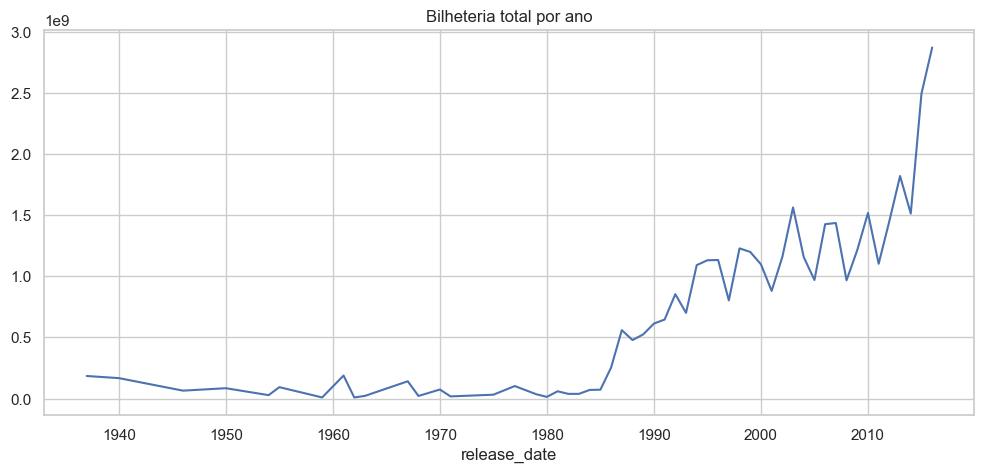

In [52]:
# 3 - Como a bilheteria evoluiu ao longo dos anos?
disney_movies.groupby(disney_movies["release_date"].dt.year)["total_gross"].sum().plot(figsize=(12,5))
plt.title("Bilheteria total por ano")
plt.show()


C:\Users\ferav\AppData\Local\Temp\ipykernel_26128\3251002220.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_genero.values, y=media_genero.index, palette="viridis")


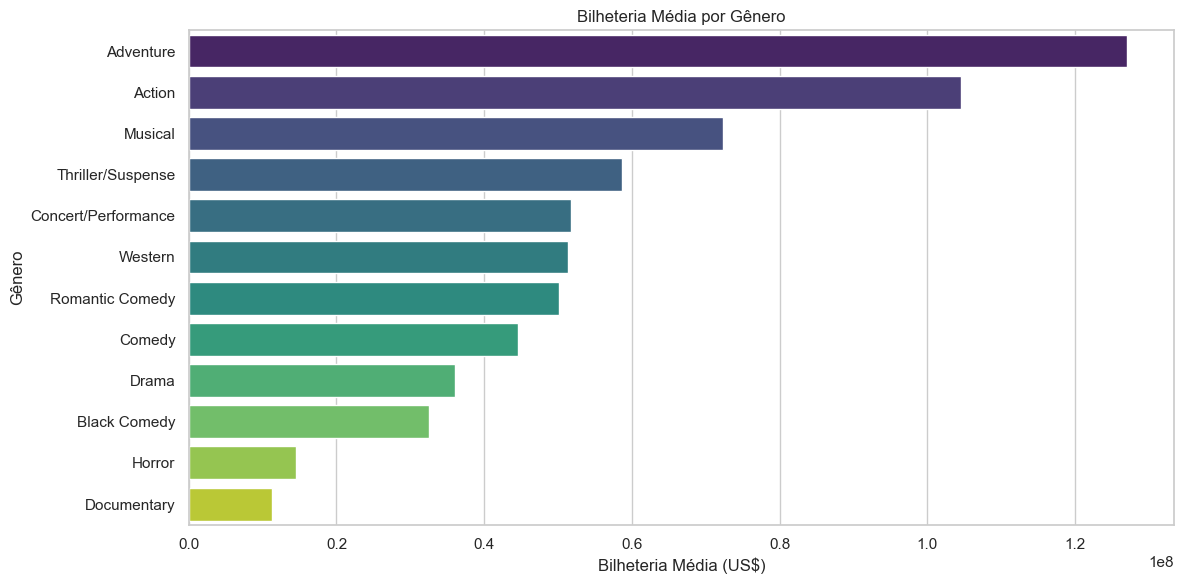

In [ ]:
# 4 - Qual gênero gera maior bilheteria média?

# Cálculo da média de bilheteria por gênero
media_genero = disney_movies.groupby("genre")["total_gross"].mean().sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12,6))
sns.barplot(x=media_genero.values, y=media_genero.index, palette="viridis")

plt.title("Bilheteria Média por Gênero")
plt.xlabel("Bilheteria Média (US$)")
plt.ylabel("Gênero")
plt.tight_layout()
plt.show()


In [55]:
#5 - Quantos filmes foram lançados por década?

disney_movies["decade"].value_counts().sort_index()


decade
1930      1
1940      3
1950      4
1960      7
1970      9
1980     61
1990    236
2000    172
2010     86
Name: count, dtype: int64

C:\Users\ferav\AppData\Local\Temp\ipykernel_26128\2808542647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=disney_movies, x="decade", palette="magma")


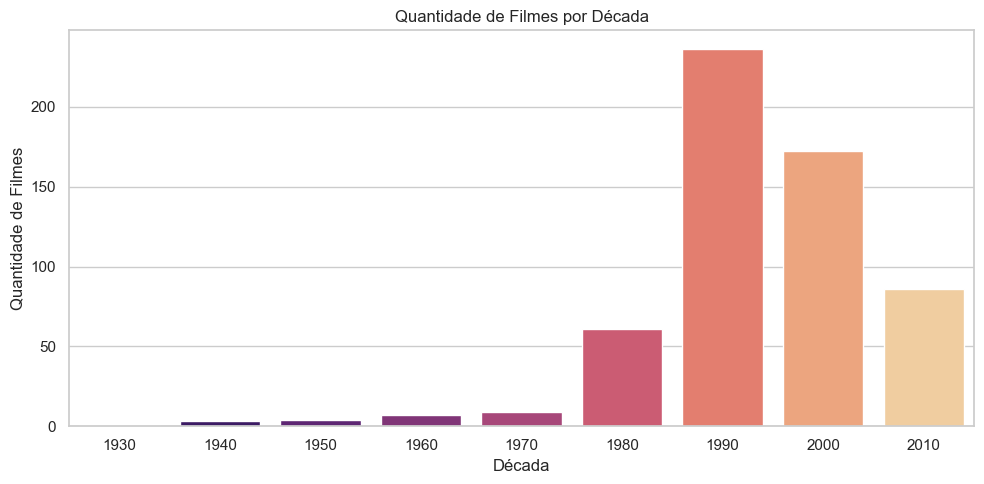

In [56]:
plt.figure(figsize=(10,5))
sns.countplot(data=disney_movies, x="decade", palette="magma")

plt.title("Quantidade de Filmes por Década")
plt.xlabel("Década")
plt.ylabel("Quantidade de Filmes")
plt.tight_layout()
plt.show()


In [58]:
# 6 - Em qual mês do ano são lançados mais filmes?
disney_movies["month"] = disney_movies["release_date"].dt.month



In [59]:
disney_movies["month"].value_counts().sort_index()


month
1     38
2     44
3     61
4     50
5     41
6     50
7     44
8     49
9     43
10    50
11    59
12    50
Name: count, dtype: int64

In [60]:
disney_movies["month"].value_counts().idxmax()


np.int32(3)

In [62]:
import calendar
calendar.month_name[disney_movies["month"].value_counts().idxmax()]


'March'

C:\Users\ferav\AppData\Local\Temp\ipykernel_26128\431863912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=disney_movies, x="month", palette="coolwarm")


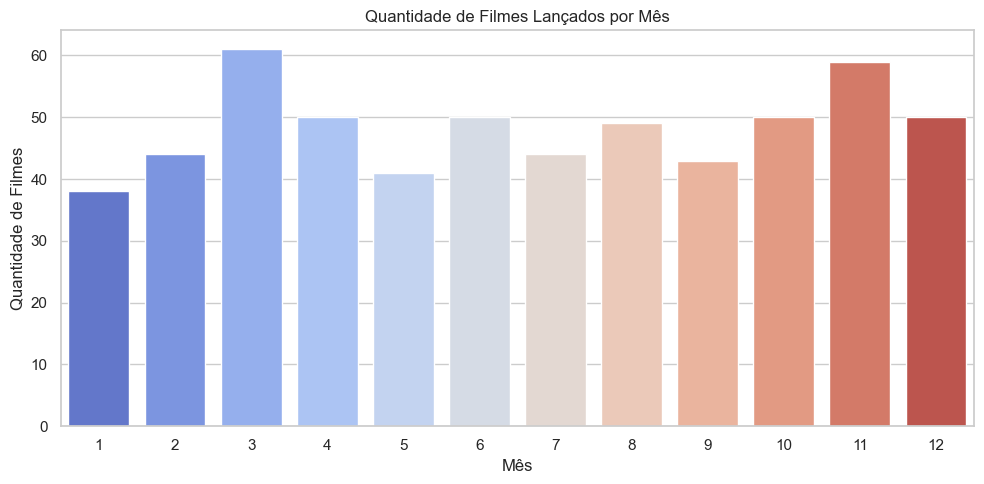

In [63]:
plt.figure(figsize=(10,5))
sns.countplot(data=disney_movies, x="month", palette="coolwarm")

plt.title("Quantidade de Filmes Lançados por Mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade de Filmes")
plt.tight_layout()
plt.show()
